# Longform 영상 긍정 댓글 비율 회귀 모델 (Gemini 임베딩)

타깃: 영상별 긍정 댓글 비율 (continuous, 0~1).
입력: long_form_all.csv 의 구조형 피쳐 + Gemini 768차원 임베딩(title+description).
모델: LGBM / RF / XGB Regressor + MLPRegressor. sample_weight 로 U자형 분포 보정 (MLP 제외).
전처리: sklearn Pipeline + ColumnTransformer + OneHotEncoder (모든 범주형 원핫). MLP 만 StandardScaler.


In [1]:
import os
import re
import time
import warnings
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

import shap
import joblib
import json as _json

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

load_dotenv(dotenv_path=Path(__file__).resolve().parent / '.env' if '__file__' in dir() else Path('.env'))
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')
GEMINI_EMBEDDING_MODEL = os.environ.get('GEMINI_EMBEDDING_MODEL', 'gemini-embedding-2')

EMBEDDING_DIM = 768
ROOT = Path('.').resolve()
EMBEDDING_CACHE_PATH = ROOT / 'embeddings' / f'gemini_emb_dim{EMBEDDING_DIM}.parquet'

print('환경 로드 완료')
print(f'  GEMINI_EMBEDDING_MODEL={GEMINI_EMBEDDING_MODEL}')
print(f'  CACHE={EMBEDDING_CACHE_PATH}')


환경 로드 완료
  GEMINI_EMBEDDING_MODEL=gemini-embedding-2
  CACHE=C:\Users\610ha\Desktop\study\final_project\works\Haeun\Dashboard\longform_comment\embeddings\gemini_emb_dim768.parquet


## 1. 영상 데이터 로드
long_form_all.csv 한 파일에 IT/FnB 성공/실패가 통합되어 있어. 1093행.


In [2]:
df_video = pd.read_csv(ROOT / 'long_form_all.csv', encoding='utf-8-sig')
print(f'video shape={df_video.shape}')
print(f'domain 분포: {df_video["domain"].value_counts().to_dict()}')


video shape=(1093, 46)
domain 분포: {'IT': 794, 'FnB': 299}


## 2. 댓글 데이터 로드 + 타깃(긍정 댓글 비율) 계산

- 4개 sentiment csv 통합 → 이벤트 댓글 제거 → 외국어 댓글 제거 → video_id 별 (긍정 댓글 수 / 전체 댓글 수)
- 댓글 없는 영상은 inner merge 에서 자동 제외


In [3]:
COMMENT_DIR = ROOT / 'data' / 'results' / 'main_dataset' / '댓글(필터링+감성분석 정보)'

df_success_IT_comment = pd.read_csv(COMMENT_DIR / 'sentiment_filtered_cleaned_it_longform_success_comment.csv', encoding='utf-8')
df_fail_IT_comment = pd.read_csv(COMMENT_DIR / 'sentiment_filtered_cleaned_it_longform_fail_comment.csv', encoding='utf-8')
df_success_FnB_comment = pd.read_csv(COMMENT_DIR / 'sentiment_fnb_longform_success_comment_final.csv', encoding='utf-8')
df_fail_FnB_comment = pd.read_csv(COMMENT_DIR / 'sentiment_filtered_cleaned_fnb_longform_fail_comment.csv', encoding='utf-8')

df_comment = pd.concat(
    [df_success_IT_comment, df_fail_IT_comment, df_success_FnB_comment, df_fail_FnB_comment],
    ignore_index=True,
)
print(f'댓글 합본: {len(df_comment)}개')


댓글 합본: 144165개


In [4]:
before = len(df_comment)
df_comment = df_comment[df_comment['is_event'] == False]
print(f'이벤트 댓글 제거: {before-len(df_comment)}개')

before = len(df_comment)
df_comment = df_comment[df_comment['is_korean'] == True].reset_index(drop=True)
print(f'외국어 댓글 제거: {before-len(df_comment)}개')


이벤트 댓글 제거: 22710개
외국어 댓글 제거: 6886개


In [5]:
agg = (
    df_comment.groupby('video_id')['sentiment']
    .agg(total='count', positive=lambda x: (x == '긍정').sum())
    .reset_index()
)
agg['target_feature'] = agg['positive'] / agg['total']

print(f'타깃 계산 영상 수: {len(agg)}')
print(agg['target_feature'].describe())


타깃 계산 영상 수: 606
count    606.000000
mean       0.683575
std        0.356826
min        0.000000
25%        0.500000
50%        0.842105
75%        0.984073
max        1.000000
Name: target_feature, dtype: float64


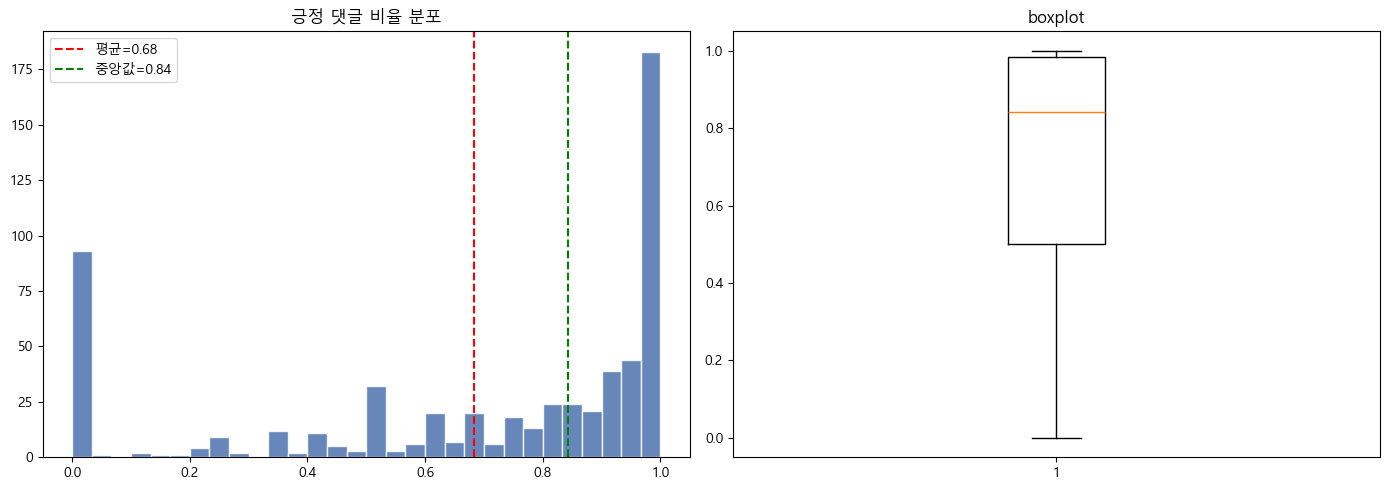

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(agg['target_feature'], bins=30, color='#4C72B0', alpha=0.85, edgecolor='white')
axes[0].axvline(agg['target_feature'].mean(), color='red', linestyle='--', label=f'평균={agg["target_feature"].mean():.2f}')
axes[0].axvline(agg['target_feature'].median(), color='green', linestyle='--', label=f'중앙값={agg["target_feature"].median():.2f}')
axes[0].set_title('긍정 댓글 비율 분포')
axes[0].legend()
axes[1].boxplot(agg['target_feature'])
axes[1].set_title('boxplot')
plt.tight_layout(); plt.show()


In [7]:
df = pd.merge(df_video, agg[['video_id', 'target_feature']], on='video_id', how='inner')
print(f'merge 후: {len(df)}개')


merge 후: 606개


## 3. Gemini 임베딩 로드 (캐시 우선)

캐시 parquet 가 있으면 그대로 쓰고, 신규 video_id 만 API 호출.
임베딩 함수들은 longform/longform_analysis_with_embedding.py 와 동일.


In [8]:
EMPTY_TEXT_SENTINEL = "(설명 없음)"
TEXT_PREFIX = "task: classification | query: "


def prepare_text(title, desc) -> str:
    title = (str(title) if title is not None and pd.notna(title) else "").strip()
    desc = (str(desc) if desc is not None and pd.notna(desc) else "").strip()
    if not desc:
        desc = EMPTY_TEXT_SENTINEL
    return f"{TEXT_PREFIX}TITLE: {title}\nDESCRIPTION: {desc}"


assert prepare_text("hello", "world") == f"{TEXT_PREFIX}TITLE: hello\nDESCRIPTION: world"
assert prepare_text(None, None) == f"{TEXT_PREFIX}TITLE: \nDESCRIPTION: {EMPTY_TEXT_SENTINEL}"
print('prepare_text OK')


prepare_text OK


In [9]:
from google import genai
from google.genai import types

_genai_client = genai.Client(api_key=GEMINI_API_KEY) if GEMINI_API_KEY else None

BATCH_SIZE = int(os.environ.get('EMBEDDING_BATCH_SIZE', '25'))
MIN_INTERVAL_BETWEEN_BATCHES = float(os.environ.get('EMBEDDING_MIN_INTERVAL', '35.0'))
MAX_RETRY = 5
RETRY_BASE_SLEEP = 2.0

_RETRY_DELAY_RE = re.compile(r"retryDelay'?:\s*'?(\d+(?:\.\d+)?)s")


def _parse_retry_delay_seconds(err: Exception):
    m = _RETRY_DELAY_RE.search(str(err))
    if not m:
        return None
    try:
        return float(m.group(1))
    except (TypeError, ValueError):
        return None


def _embed_batch(texts):
    last_err = None
    for attempt in range(MAX_RETRY):
        try:
            resp = _genai_client.models.embed_content(
                model=GEMINI_EMBEDDING_MODEL,
                contents=texts,
                config=types.EmbedContentConfig(output_dimensionality=EMBEDDING_DIM),
            )
            return [list(e.values) for e in resp.embeddings]
        except Exception as e:
            last_err = e
            err_str = str(e)
            if '429' in err_str or 'RESOURCE_EXHAUSTED' in err_str:
                hinted = _parse_retry_delay_seconds(e)
                sleep_s = (hinted + 2.0) if hinted is not None else 60.0
                print(f'[WARN] rate limit (attempt {attempt+1}/{MAX_RETRY}). sleep {sleep_s:.1f}s')
            else:
                sleep_s = RETRY_BASE_SLEEP * (2 ** attempt)
                print(f'[WARN] embed batch failed: {e}. sleep {sleep_s:.1f}s')
            time.sleep(sleep_s)
    raise RuntimeError(f'임베딩 생성 실패 ({MAX_RETRY}회 재시도): {last_err}')


def embed_texts(texts):
    all_vecs = []
    last_call_t = 0.0
    batch_iter = list(range(0, len(texts), BATCH_SIZE))
    for bi, i in enumerate(tqdm(batch_iter, desc='embedding')):
        if bi > 0:
            wait = MIN_INTERVAL_BETWEEN_BATCHES - (time.time() - last_call_t)
            if wait > 0:
                time.sleep(wait)
        chunk = texts[i:i + BATCH_SIZE]
        vecs = _embed_batch(chunk)
        last_call_t = time.time()
        if len(vecs) != len(chunk):
            raise RuntimeError(f'배치 응답 길이 불일치: req={len(chunk)} resp={len(vecs)}')
        all_vecs.extend(vecs)
    arr = np.array(all_vecs, dtype=np.float32)
    if arr.shape != (len(texts), EMBEDDING_DIM):
        raise RuntimeError(f'임베딩 shape 불일치: {arr.shape}')
    return arr


In [10]:
def load_or_create_embeddings(df: pd.DataFrame) -> pd.DataFrame:
    EMBEDDING_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

    if EMBEDDING_CACHE_PATH.exists():
        cache_df = pd.read_parquet(EMBEDDING_CACHE_PATH)
        print(f'[CACHE] {len(cache_df)}건 로드')
    else:
        cache_df = pd.DataFrame({'video_id': pd.Series(dtype=str), 'embedding': pd.Series(dtype=object)})
        print('[CACHE] 캐시 없음 — 신규 생성')

    cached_ids = set(cache_df['video_id'].tolist())
    needed = df[~df['video_id'].isin(cached_ids)][['video_id', 'title', 'description']].copy()
    needed = needed.drop_duplicates(subset='video_id').reset_index(drop=True)
    print(f'[CACHE] 신규 임베딩 필요: {len(needed)} / {len(df)}')

    if len(needed) > 0:
        if _genai_client is None:
            raise RuntimeError('GEMINI_API_KEY 가 설정되지 않아 신규 임베딩을 만들 수 없습니다.')
        texts = [prepare_text(t, d) for t, d in zip(needed['title'], needed['description'])]
        vectors = embed_texts(texts)
        new_df = pd.DataFrame({
            'video_id': needed['video_id'].tolist(),
            'embedding': [v.tolist() for v in vectors],
        })
        merged = pd.concat([cache_df, new_df], ignore_index=True)
        merged = merged.drop_duplicates(subset='video_id', keep='last').reset_index(drop=True)
        tmp = EMBEDDING_CACHE_PATH.with_suffix('.parquet.tmp')
        merged.to_parquet(tmp, index=False)
        tmp.replace(EMBEDDING_CACHE_PATH)
        print(f'[CACHE] 저장 완료: {len(merged)}건')
        cache_df = merged

    result = df[['video_id']].merge(cache_df, on='video_id', how='left')
    missing = result['embedding'].isna().sum()
    if missing > 0:
        raise RuntimeError(f'임베딩 누락 video_id {missing}건')
    return result


In [11]:
emb_df = load_or_create_embeddings(df)
print(f'emb rows={len(emb_df)}, dim={len(emb_df["embedding"].iloc[0])}')
assert len(emb_df['embedding'].iloc[0]) == EMBEDDING_DIM


[CACHE] 1093건 로드
[CACHE] 신규 임베딩 필요: 0 / 606
emb rows=606, dim=768


In [12]:
def expand_embeddings(emb_df: pd.DataFrame) -> pd.DataFrame:
    arr = np.vstack(emb_df['embedding'].to_list()).astype(np.float32)
    cols = [f'emb_{i}' for i in range(arr.shape[1])]
    out = pd.DataFrame(arr, columns=cols)
    out.insert(0, 'video_id', emb_df['video_id'].values)
    return out

emb_wide = expand_embeddings(emb_df)
df_full = df.merge(emb_wide, on='video_id', how='left')
emb_cols_check = [f'emb_{i}' for i in range(EMBEDDING_DIM)]
assert df_full[emb_cols_check].isna().sum().sum() == 0
print(f'df_full shape={df_full.shape}')


df_full shape=(606, 815)


## 4. 피쳐 정의

embedding.py 의 구조형 피쳐 셋 + domain (사용자가 분기 키 대신 일반 피쳐로 사용 요청)
+ Gemini 임베딩 768차원.


In [13]:
structured_feature_cols = [
    'domain',
    'description_missing_flag',
    'tags_missing_flag', 'tags_count',
    '영상길이(초)',
    'caption',
    'category_name',
    'length_bucket',
    'cls_content_type', 'cls_marketing_purpose', 'cls_cta_type',
    'cls_is_series', 'cls_is_collaboration',
    'definition',
    'embeddable',
    'has_paid_product_placement',
]
embedding_feature_cols = [f'emb_{i}' for i in range(EMBEDDING_DIM)]
all_feature_cols = structured_feature_cols + embedding_feature_cols
TARGET = 'target_feature'

missing = [c for c in all_feature_cols if c not in df_full.columns]
assert not missing, f'feature 누락: {missing}'

df_model = df_full[all_feature_cols + [TARGET]].copy()
print(f'df_model shape={df_model.shape}, structured={len(structured_feature_cols)}, embedding={len(embedding_feature_cols)}')


df_model shape=(606, 785), structured=16, embedding=768


## 5. 전처리 파이프라인

- 임베딩: passthrough (SDK 가 L2 정규화 처리)
- 구조형 수치: median 보간
- 구조형 범주: 'missing' 채움 + OneHotEncoder(handle_unknown='ignore')


In [14]:
def split_columns(X: pd.DataFrame):
    emb = [c for c in X.columns if c.startswith('emb_')]
    non_emb = [c for c in X.columns if c not in emb]
    sub = X[non_emb]
    num = sub.select_dtypes(include=['number']).columns.tolist()
    cat = sub.select_dtypes(exclude=['number']).columns.tolist()
    return emb, num, cat


def prepare_categorical_str(X: pd.DataFrame, cat_cols):
    X = X.copy()
    for c in cat_cols:
        X[c] = X[c].where(X[c].notna(), 'missing').astype(str)
    return X


def make_preprocessor(X: pd.DataFrame, scale_numeric: bool = False) -> ColumnTransformer:
    """공통 전처리. MLP 처럼 스케일링이 필요하면 scale_numeric=True 로 호출.

    - 임베딩: passthrough (SDK 가 L2 정규화 처리)
    - 구조형 수치: median 보간 (+ MLP 일 때만 StandardScaler 추가)
    - 구조형 범주: 'missing' 채움 + OneHotEncoder(handle_unknown='ignore')
    """
    emb, num, cat = split_columns(X)
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    numeric_pipe = Pipeline(steps=num_steps)
    categorical_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    transformers = []
    if emb:
        transformers.append(('emb', 'passthrough', emb))
    if num:
        transformers.append(('num', numeric_pipe, num))
    if cat:
        transformers.append(('cat', categorical_pipe, cat))
    return ColumnTransformer(transformers=transformers, remainder='drop')


_emb, _num, _cat = split_columns(df_model[all_feature_cols])
print(f'split: emb={len(_emb)}, num={len(_num)}, cat={len(_cat)}')
print(f'cat 컬럼: {_cat}')


split: emb=768, num=4, cat=12
cat 컬럼: ['domain', 'caption', 'category_name', 'length_bucket', 'cls_content_type', 'cls_marketing_purpose', 'cls_cta_type', 'cls_is_series', 'cls_is_collaboration', 'definition', 'embeddable', 'has_paid_product_placement']


## 6. 데이터 분할 + sample_weight (U자형 분포 보정)


In [15]:
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.01]
labels = [0, 1, 2, 3, 4]
target_bin = pd.cut(df_model[TARGET], bins=bins, labels=labels, include_lowest=True)
print('[구간 분포]')
print(target_bin.value_counts().sort_index())

sample_weights = compute_sample_weight(class_weight='balanced', y=target_bin)
print(f'\n[가중치] min={sample_weights.min():.3f}, max={sample_weights.max():.3f}, mean={sample_weights.mean():.3f}')


[구간 분포]
target_feature
0    100
1     32
2     66
3     85
4    323
Name: count, dtype: int64

[가중치] min=0.375, max=3.788, mean=1.000


In [16]:
X = df_model[all_feature_cols].copy()
y = df_model[TARGET].copy()

_, _, cat_cols = split_columns(X)
X = prepare_categorical_str(X, cat_cols)

X_train, X_test, y_train, y_test, w_train, w_test, idx_train, idx_test = train_test_split(
    X, y, sample_weights, np.arange(len(df_model)),
    test_size=0.2, random_state=42, stratify=target_bin,
)
target_bin_train = target_bin.iloc[idx_train].reset_index(drop=True)

print(f'train={len(X_train)}, test={len(X_test)}')


train=484, test=122


In [17]:
SAVE_DIR = ROOT / 'models'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

X_train.assign(target_feature=y_train.values).to_csv(ROOT / 'train_data.csv', index=False, encoding='utf-8')
X_test.assign(target_feature=y_test.values).to_csv(ROOT / 'test_data.csv', index=False, encoding='utf-8')
pd.DataFrame({'sample_weight': w_train}).to_csv(ROOT / 'train_weights.csv', index=False, encoding='utf-8')

meta = {
    'structured_feature_cols': structured_feature_cols,
    'embedding_feature_cols': embedding_feature_cols,
    'all_feature_cols': all_feature_cols,
    'target': TARGET,
    'embedding_dim': EMBEDDING_DIM,
    'gemini_model': GEMINI_EMBEDDING_MODEL,
}
(SAVE_DIR / 'meta.json').write_text(_json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')
print('데이터 + meta.json 저장 완료')


데이터 + meta.json 저장 완료


## 7. 기본 모델 비교 (CV)
sample_weight 는 Pipeline 인터페이스에서 `model__sample_weight` 로 전달.


In [18]:
def make_pipeline(estimator, scale_numeric: bool = False):
    return Pipeline(steps=[
        ('preprocess', make_preprocessor(X_train, scale_numeric=scale_numeric)),
        ('model', estimator),
    ])


# (estimator, scale_numeric, supports_sample_weight) 튜플로 관리.
# MLPRegressor 는 sklearn 의 fit 시그니처에 sample_weight 가 없어서 U자 보정을 못 받음.
# 대신 임베딩 768차원이 강한 신호라 가중치 없이도 합리적인 결과가 나올 수 있다.
default_models = {
    'LightGBM'    : (LGBMRegressor(random_state=42, verbose=-1), False, True),
    'RandomForest': (RandomForestRegressor(random_state=42), False, True),
    'XGBoost'     : (XGBRegressor(random_state=42), False, True),
    'MLP'         : (
        MLPRegressor(
            hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
            alpha=1e-4, batch_size=64, learning_rate_init=1e-3,
            max_iter=200, early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=10, random_state=42,
        ),
        True,   # scale_numeric: MLP 는 입력 스케일에 민감
        False,  # sample_weight 미지원
    ),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
default_results = {}

for name, (est, scale_num, supports_sw) in default_models.items():
    rmses, maes, r2s = [], [], []
    for tr, va in skf.split(X_train, target_bin_train):
        X_tr, X_va = X_train.iloc[tr], X_train.iloc[va]
        y_tr, y_va = y_train.iloc[tr], y_train.iloc[va]
        w_tr = w_train[tr]
        pipe = make_pipeline(est.__class__(**est.get_params()), scale_numeric=scale_num)
        if supports_sw:
            pipe.fit(X_tr, y_tr, model__sample_weight=w_tr)
        else:
            pipe.fit(X_tr, y_tr)
        p = pipe.predict(X_va)
        rmses.append(np.sqrt(mean_squared_error(y_va, p)))
        maes.append(mean_absolute_error(y_va, p))
        r2s.append(r2_score(y_va, p))
    default_results[name] = {'RMSE': np.mean(rmses), 'MAE': np.mean(maes), 'R²': np.mean(r2s)}
    print(f'[{name}] RMSE={np.mean(rmses):.4f} (±{np.std(rmses):.4f}), MAE={np.mean(maes):.4f}, R²={np.mean(r2s):.4f}')


[LightGBM] RMSE=0.2860 (±0.0093), MAE=0.2209, R²=0.3541
[RandomForest] RMSE=0.2766 (±0.0148), MAE=0.2214, R²=0.3947
[XGBoost] RMSE=0.2831 (±0.0198), MAE=0.2138, R²=0.3646
[MLP] RMSE=0.2993 (±0.0450), MAE=0.2302, R²=0.2768


## 8. 하이퍼파라미터 튜닝 (GridSearchCV)
Pipeline 위에서 `model__` prefix 로 파라미터 전달.

NOTE: 첫 실행 검증용으로 그리드가 작게 잡혀 있어. 본격 학습 시에는 그리드를 늘려서 다시 실행.


In [19]:
param_grid_lgb = {
    'model__num_leaves':        [15, 25],
    'model__min_child_samples': [20, 30],
    'model__learning_rate':     [0.01, 0.05],
    'model__n_estimators':      [200, 400],
    'model__max_depth':         [5, 7],
}

pipe_lgb = make_pipeline(LGBMRegressor(random_state=42, verbose=-1))
grid_lgb = GridSearchCV(
    estimator=pipe_lgb,
    param_grid=param_grid_lgb,
    cv=list(skf.split(X_train, target_bin_train)),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
grid_lgb.fit(X_train, y_train, model__sample_weight=w_train)
print(f'best_params={grid_lgb.best_params_}')
print(f'best CV RMSE={-grid_lgb.best_score_:.4f}')


Fitting 5 folds for each of 32 candidates, totalling 160 fits
best_params={'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_samples': 30, 'model__n_estimators': 400, 'model__num_leaves': 15}
best CV RMSE=0.2763


In [20]:
param_grid_rf = {
    'model__n_estimators':      [200, 400],
    'model__max_depth':         [None, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf':  [1, 2],
    'model__max_features':      ['sqrt', 'log2'],
}

pipe_rf = make_pipeline(RandomForestRegressor(random_state=42))
grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=list(skf.split(X_train, target_bin_train)),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
grid_rf.fit(X_train, y_train, model__sample_weight=w_train)
print(f'best_params={grid_rf.best_params_}')
print(f'best CV RMSE={-grid_rf.best_score_:.4f}')


Fitting 5 folds for each of 32 candidates, totalling 160 fits
best_params={'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 400}
best CV RMSE=0.2830


In [21]:
param_grid_xgb = {
    'model__n_estimators':     [200, 400],
    'model__max_depth':        [5, 7],
    'model__learning_rate':    [0.01, 0.05],
    'model__subsample':        [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
}

pipe_xgb = make_pipeline(XGBRegressor(random_state=42))
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=list(skf.split(X_train, target_bin_train)),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
grid_xgb.fit(X_train, y_train, model__sample_weight=w_train)
print(f'best_params={grid_xgb.best_params_}')
print(f'best CV RMSE={-grid_xgb.best_score_:.4f}')


Fitting 5 folds for each of 32 candidates, totalling 160 fits
best_params={'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 400, 'model__subsample': 0.8}
best CV RMSE=0.2665


In [22]:
# MLP 튜닝 (sample_weight 미지원이라 U자 보정 없이 학습).
# 임베딩 768차원이 강한 신호라 작은 그리드로도 합리적 결과 기대.
param_grid_mlp = {
    'model__hidden_layer_sizes': [(128, 64, 32), (256, 128, 64)],
    'model__alpha':              [1e-4, 1e-3],
    'model__learning_rate_init': [1e-3, 5e-4],
}

pipe_mlp = make_pipeline(
    MLPRegressor(
        activation='relu', solver='adam', batch_size=64,
        max_iter=200, early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=10, random_state=42,
    ),
    scale_numeric=True,
)
grid_mlp = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=param_grid_mlp,
    cv=list(skf.split(X_train, target_bin_train)),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
grid_mlp.fit(X_train, y_train)
print(f'best_params={grid_mlp.best_params_}')
print(f'best CV RMSE={-grid_mlp.best_score_:.4f}')


Fitting 5 folds for each of 8 candidates, totalling 40 fits
best_params={'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128, 64, 32), 'model__learning_rate_init': 0.001}
best CV RMSE=0.2815


## 9. 최종 평가 (Test set)


In [23]:
final_models = {
    'LightGBM'    : grid_lgb.best_estimator_,
    'RandomForest': grid_rf.best_estimator_,
    'XGBoost'     : grid_xgb.best_estimator_,
    'MLP'         : grid_mlp.best_estimator_,
}

final_results = {}
for name, pipe in final_models.items():
    p = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, p))
    mae = mean_absolute_error(y_test, p)
    r2 = r2_score(y_test, p)
    final_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    print(f'[{name}] RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}')

best_name = min(final_results, key=lambda k: final_results[k]['RMSE'])
print(f'\nbest = {best_name}')


[LightGBM] RMSE=0.2757, MAE=0.2143, R²=0.4070
[RandomForest] RMSE=0.2775, MAE=0.2360, R²=0.3990
[XGBoost] RMSE=0.2682, MAE=0.2112, R²=0.4388
[MLP] RMSE=0.2580, MAE=0.2027, R²=0.4805

best = MLP


In [24]:
for name, pipe in final_models.items():
    out = SAVE_DIR / f'{name}.joblib'
    joblib.dump(pipe, out, compress=3)
    print(f'saved {out.name}')

best_pipe = final_models[best_name]
joblib.dump(best_pipe, SAVE_DIR / 'longform_comment_model.joblib', compress=3)
(SAVE_DIR / 'best_model.json').write_text(_json.dumps({'best_model': best_name, **final_results[best_name]}, indent=2), encoding='utf-8')
print(f'\nbest 모델 저장: {best_name}')


saved LightGBM.joblib
saved RandomForest.joblib
saved XGBoost.joblib
saved MLP.joblib

best 모델 저장: MLP


## 10. SHAP 변수 영향력 분석

- 트리 모델은 Pipeline 의 preprocessor 통과 후 행렬을 TreeExplainer 에 넘긴다.
- 768차원 임베딩은 'embedding(sum)' 한 그룹으로 묶어서 시각화.


In [25]:
_CT_PREFIXES = ('emb__', 'num__', 'cat__')


def strip_ct_prefix(name: str) -> str:
    for p in _CT_PREFIXES:
        if name.startswith(p):
            return name[len(p):]
    return name


def is_embedding_dim(name: str) -> bool:
    return name.startswith('emb_') and name[4:].isdigit()


def group_feature_name(name: str, structured_cols):
    name = strip_ct_prefix(name)
    if is_embedding_dim(name):
        return 'embedding(sum)'
    if name in structured_cols:
        return name
    for orig in structured_cols:
        if name.startswith(orig + '_'):
            return orig
    return name


[SHAP] best=MLP (비-트리) → tree fallback=XGBoost
X=(484, 834), SHAP=(484, 834)

[SHAP grouped (top 20)]
                     group  mean_abs_shap     mean_shap
            embedding(sum)       0.630160  1.846098e-01
     cls_marketing_purpose       0.062267  1.353250e-02
              cls_cta_type       0.026488  9.365063e-03
             cls_is_series       0.009535  1.246500e-03
                tags_count       0.002312  3.016857e-04
                   영상길이(초)       0.000723 -2.467270e-05
                   caption       0.000289  1.772675e-04
          cls_content_type       0.000226  9.686413e-05
                    domain       0.000193  3.275726e-05
         tags_missing_flag       0.000044  2.091412e-05
      cls_is_collaboration       0.000002 -2.765323e-08
             category_name       0.000000  0.000000e+00
                definition       0.000000  0.000000e+00
  description_missing_flag       0.000000  0.000000e+00
                embeddable       0.000000  0.000000e+00
ha

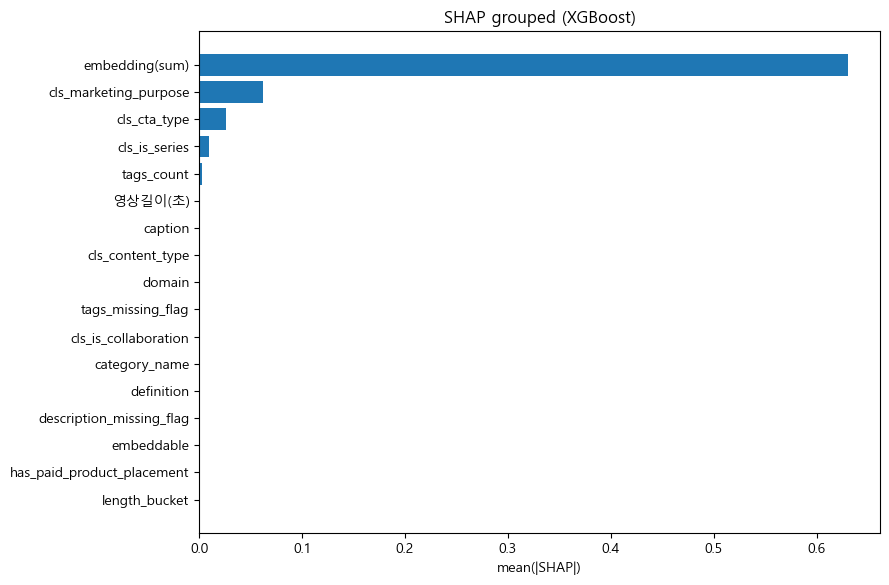

In [26]:
# SHAP 는 TreeExplainer 만 사용. MLP 가 best 면 트리 중 RMSE 최소 모델로 fallback.
_TREE_NAMES = {'LightGBM', 'RandomForest', 'XGBoost'}
if best_name in _TREE_NAMES:
    shap_model_name = best_name
    shap_pipe = best_pipe
else:
    _tree_results = {k: v for k, v in final_results.items() if k in _TREE_NAMES}
    shap_model_name = min(_tree_results, key=lambda k: _tree_results[k]['RMSE'])
    shap_pipe = final_models[shap_model_name]
    print(f'[SHAP] best={best_name} (비-트리) → tree fallback={shap_model_name}')

preprocessor = shap_pipe.named_steps['preprocess']
model = shap_pipe.named_steps['model']

X_train_trans = preprocessor.transform(X_train)
if hasattr(X_train_trans, 'toarray'):
    X_train_trans = X_train_trans.toarray()

feature_names = [strip_ct_prefix(n) for n in preprocessor.get_feature_names_out()]

explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_train_trans)
if isinstance(sv, list):
    sv = sv[0]
print(f'X={X_train_trans.shape}, SHAP={np.array(sv).shape}')

shap_table = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(sv).mean(axis=0),
    'mean_shap': sv.mean(axis=0),
})
shap_table['group'] = shap_table['feature'].map(lambda n: group_feature_name(n, structured_feature_cols))
grouped = (
    shap_table.groupby('group', as_index=False)
    .agg(mean_abs_shap=('mean_abs_shap', 'sum'), mean_shap=('mean_shap', 'sum'))
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)
print('\n[SHAP grouped (top 20)]')
print(grouped.head(20).to_string(index=False))

top = grouped.head(20).iloc[::-1]
plt.figure(figsize=(9, max(4, 0.35 * len(top))))
plt.barh(top['group'], top['mean_abs_shap'])
plt.xlabel('mean(|SHAP|)')
plt.title(f'SHAP grouped ({shap_model_name})')
plt.tight_layout(); plt.show()


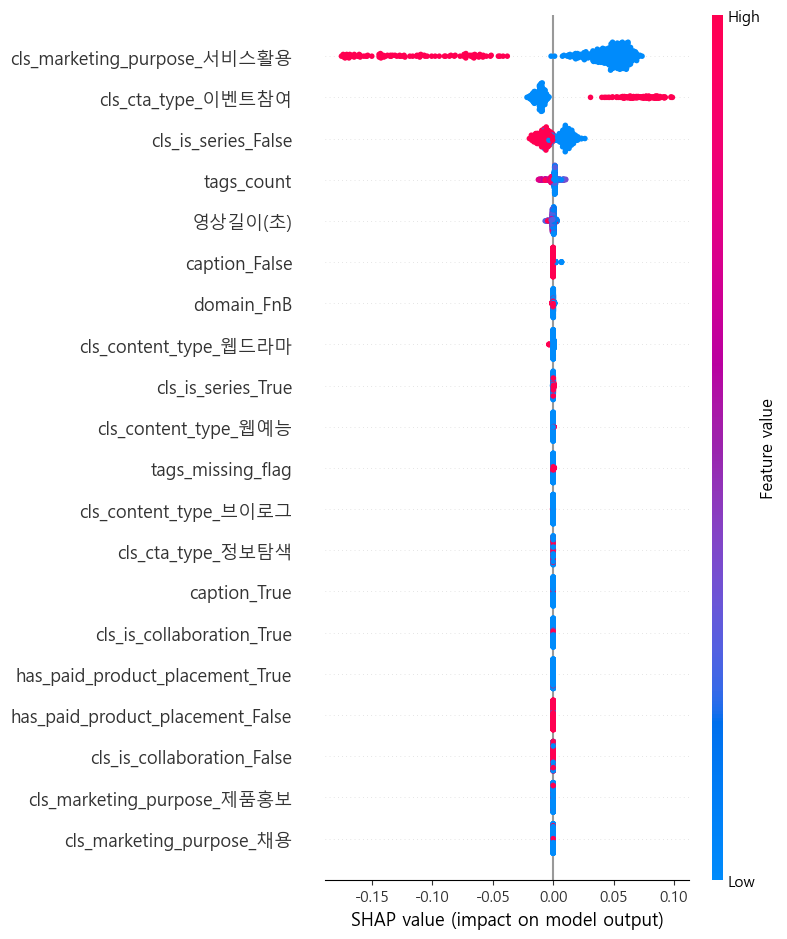

In [27]:
struct_set = set(structured_feature_cols)
keep_idx, keep_names = [], []
for i, name in enumerate(feature_names):
    bare = strip_ct_prefix(name)
    if is_embedding_dim(bare):
        continue
    if bare in struct_set:
        keep_idx.append(i); keep_names.append(bare); continue
    for orig in structured_feature_cols:
        if bare.startswith(orig + '_'):
            keep_idx.append(i); keep_names.append(bare); break

if keep_idx:
    shap_struct = sv[:, keep_idx]
    X_struct = pd.DataFrame(X_train_trans[:, keep_idx], columns=keep_names)
    shap.summary_plot(shap_struct, X_struct, feature_names=keep_names, show=True)
else:
    print('구조형 컬럼 매칭 없음 - dot plot skip')


## 11. 예측 함수

raw 문자열/수치 dict 입력 → Pipeline 이 알아서 원핫/imputer 처리.
임베딩은 video_id 로 캐시 lookup (없으면 0벡터 fallback).


In [28]:
_emb_lookup = emb_wide.set_index('video_id')[embedding_feature_cols]


def predict_positive_ratio(input_data: dict) -> None:
    vid = input_data.get('video_id')

    row = {c: input_data.get(c) for c in structured_feature_cols}
    df_in = pd.DataFrame([row])

    if vid is not None and vid in _emb_lookup.index:
        emb_row = _emb_lookup.loc[vid].values
    else:
        print(f'[WARN] video_id={vid} 임베딩 캐시에 없음 - 0벡터 fallback')
        emb_row = np.zeros(EMBEDDING_DIM, dtype=np.float32)
    for i, c in enumerate(embedding_feature_cols):
        df_in[c] = emb_row[i]

    df_in = df_in[all_feature_cols]
    _, _, cat_local = split_columns(df_in)
    df_in = prepare_categorical_str(df_in, cat_local)

    pred = float(np.clip(best_pipe.predict(df_in)[0], 0, 1))
    all_preds = best_pipe.predict(X_train)
    percentile = (all_preds < pred).mean() * 100

    print(f'예측 긍정 댓글 비율: {pred:.4f} ({pred*100:.1f}%)')
    print(f'학습 데이터 내 상위 {100-percentile:.1f}%')


In [30]:
sample_vid = df.iloc[3]['video_id']
sample_input = {'video_id': sample_vid}
for c in structured_feature_cols:
    val = df.iloc[0][c]
    sample_input[c] = val if pd.notna(val) else None

predict_positive_ratio(sample_input)


예측 긍정 댓글 비율: 0.8549 (85.5%)
학습 데이터 내 상위 29.8%
